In [145]:
'''
the propose of this notebook is to model and test how the ASGAE works on the task of anomally detection on social media
'''



'''
- get acess to carc
- get the embeddings of the IO hunter, rum the another model
- the embeddings are on the data
'''


import pickle
import torch
import networkx as nx
import numpy as np
from pathlib import Path
from torch_geometric.utils import from_networkx
from model.data_loader import * 
from sklearn.model_selection import train_test_split

data_path = Path("../../data/processed/china")

dl = load_dataset(data_path,undersampling=0.9)




In [112]:
dl['splits'][0]['val'].size

716

In [88]:
x.size(),len(dl['labels'])

(torch.Size([716, 768]), 716)

In [129]:
def clear(g):
    g = g.copy()
    self_edges = [(u,v) for u,v in g.edges if u == v]
    g.remove_edges_from(self_edges)
    self_nodes = [u for u,d in g.degree() if d == 0]
    g.remove_nodes_from(self_nodes)
    return g


In [146]:


# Original data
G_original = dl["graph"]
labels_original = torch.tensor(dl["labels"], dtype=torch.long)

x_original = torch.load(
    data_path / "sbert_nodeattributes_mostPop5.pt",
    map_location="cpu"
).float()

# Apply your pruning function
G_pruned = clear(G_original)

# Nodes that survived after pruning
surviving_nodes = sorted(list(G_pruned.nodes()))

# Filter labels and embeddings
labels = labels_original[surviving_nodes]
x = x_original[surviving_nodes]

# Relabel graph to 0, 1, 2, ..., new_n - 1
mapping = {
    old_id: new_id
    for new_id, old_id in enumerate(surviving_nodes)
}

G = nx.relabel_nodes(G_pruned, mapping, copy=True)

# Convert NetworkX graph to PyG Data
data = from_networkx(G)

# Add node features
data.x = x

# Add anomaly labels
data.anomaly_flag = labels.bool()

# Safety checks
assert data.x.shape[0] == data.num_nodes
assert data.anomaly_flag.shape[0] == data.num_nodes
assert data.edge_index.max().item() < data.num_nodes
assert data.edge_index.min().item() >= 0

print(data)
print("Nodes:", data.num_nodes)
print("Edges:", data.edge_index.shape[1])
print("Features:", data.num_features)
print("Anomalies:", data.anomaly_flag.sum().item())

# Save in the format expected by the anomaly model
out_dir = Path("data/real_world/")
out_dir.mkdir(parents=True, exist_ok=True)

with open(out_dir / "china.pkl", "wb") as f:
    pickle.dump(data, f)

Data(edge_index=[2, 777760], weight=[777760], num_nodes=22694, x=[22694, 768], anomaly_flag=[22694])
Nodes: 22694
Edges: 777760
Features: 768
Anomalies: 691


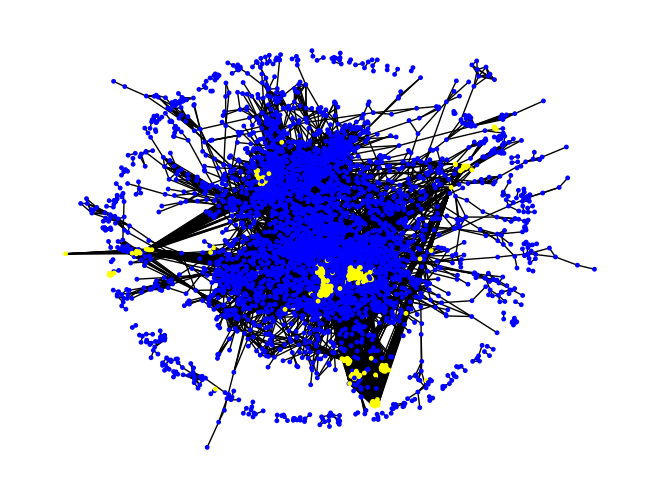

In [142]:
G = G_pruned.copy()


pos  = nx.spring_layout(G)
colors = ['yellow' if dl['labels'][u] == 1. else 'blue' for u in G.nodes]

nx.draw(G,pos,node_color=colors,node_size=6)

In [136]:
!ls

ASGAE.ipynb  env      model	pytorch_scatter   results
data	     main.py  model.pt	requirements.txt
